# 01 — Data & EDA: Plant Health Classification

**Dataset:** ziya07/plant-health-monitoring  
**Features:** temperature, air_humidity, soil_moisture  
**Target:** health_status


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import subprocess

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / '../dataset/raw'
MODEL_DIR = BASE_DIR / '../models'

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

csv_path = DATA_DIR / 'plant_health.csv'
print('Packages OK')

Packages OK


In [ ]:
if not csv_path.exists():
    try:
        result = subprocess.run(
            ['kaggle','datasets','download','-d','ziya07/plant-health-data','--unzip','-p',str(DATA_DIR)],
            capture_output=True,
            text=True
        )
        print(result.stdout or result.stderr)

        files = list(DATA_DIR.glob('*.csv'))
        if files:
            files[0].rename(csv_path)

    except FileNotFoundError:
        print('Kaggle CLI not installed')

if not csv_path.exists():
    raise FileNotFoundError(f'Missing dataset: {csv_path}')

print('Dataset ready:', csv_path)

Dataset ready: /Users/duongbinh/Documents/M1/Sensor_to_user/Projects/mushroom-aiot-project/ai_analytics/notebooks/../dataset/raw/plant_health.csv


In [33]:
df = pd.read_csv(csv_path)
print(df.shape)
print(df.columns.tolist())
df.head()

(1000, 9)
['Plant_ID', 'Temperature_C', 'Humidity_%', 'Soil_Moisture_%', 'Soil_pH', 'Nutrient_Level', 'Light_Intensity_lux', 'Health_Score', 'Health_Status']


,Plant_ID,Temperature_C,Humidity_%,Soil_Moisture_%,Soil_pH,Nutrient_Level,Light_Intensity_lux,Health_Score,Health_Status
0,Plant_1,26.490142,73.993554,34.872326,5.546096,41.365064,18728.720954,68.859186,0
1,Plant_2,24.585207,69.246337,42.832220,6.069807,49.687965,18639.757675,73.690692,1
2,Plant_3,26.943066,60.596304,33.113701,6.293197,50.180169,14613.070482,70.579398,1
3,Plant_4,29.569090,53.530632,40.380577,7.443844,54.726303,19009.729425,74.520042,1
4,Plant_5,24.297540,66.982233,16.595780,6.778277,36.331416,22198.487245,77.858497,1


In [34]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_', regex=False)

column_mapping = {
    'temperature_c': 'temperature',
    'humidity_%': 'air_humidity',
    'soil_moisture_%': 'soil_moisture',
    'health_status': 'health_status'
}

df = df.rename(columns=column_mapping)

required_cols = ['temperature', 'air_humidity', 'soil_moisture', 'health_status']
df = df[required_cols].dropna().copy()

df.head()

,temperature,air_humidity,soil_moisture,health_status
0,26.490142,73.993554,34.872326,0
1,24.585207,69.246337,42.832220,1
2,26.943066,60.596304,33.113701,1
3,29.569090,53.530632,40.380577,1
4,24.297540,66.982233,16.595780,1


In [35]:
df = df.dropna()

if 'health_status' not in df.columns:
    raise KeyError(f"health_status column missing. Available columns: {df.columns.tolist()}")

raw_labels = df['health_status'].astype(str).str.lower().str.strip()

label_map = {}

for lbl in raw_labels.unique():
    if 'healthy' in lbl:
        label_map[lbl] = 0
    elif 'warn' in lbl or 'moderate' in lbl:
        label_map[lbl] = 1
    else:
        label_map[lbl] = 2

df['label'] = raw_labels.map(label_map)
CLASS_NAMES = {0: 'healthy', 1: 'warning', 2: 'critical'}

print(label_map)

{'0': 2, '1': 2}


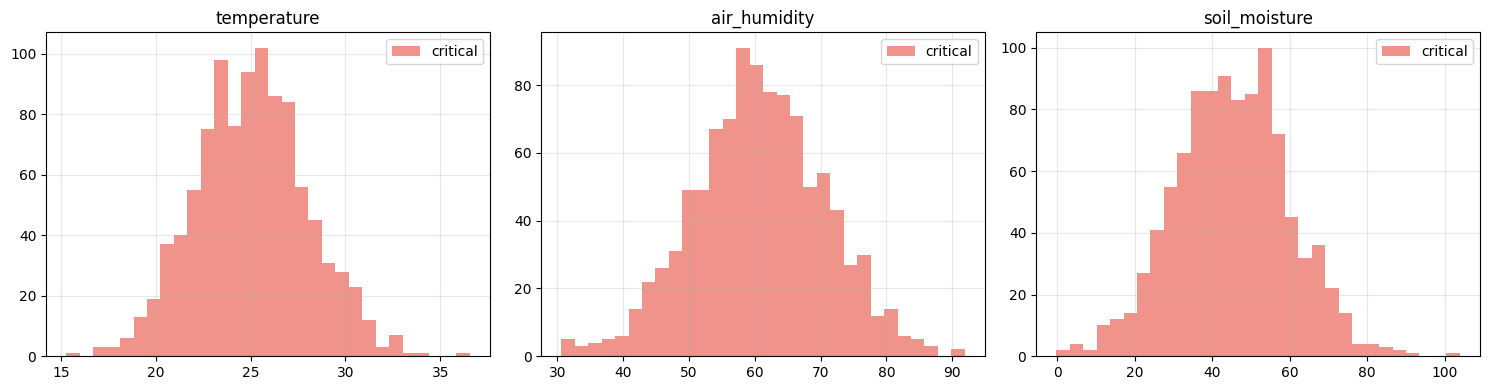

In [36]:
FEATURES = ['temperature','air_humidity','soil_moisture']
palette = {0:'#2ecc71',1:'#f39c12',2:'#e74c3c'}

fig, axes = plt.subplots(1,3,figsize=(15,4))

for ax, feat in zip(axes, FEATURES):
    for lbl, color in palette.items():
        subset = df[df['label']==lbl]
        if not subset.empty:
            subset[feat].hist(ax=ax,bins=30,alpha=0.6,color=color,label=CLASS_NAMES.get(lbl,str(lbl)))

    ax.set_title(feat)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR/'feature_distribution.png')
plt.show()

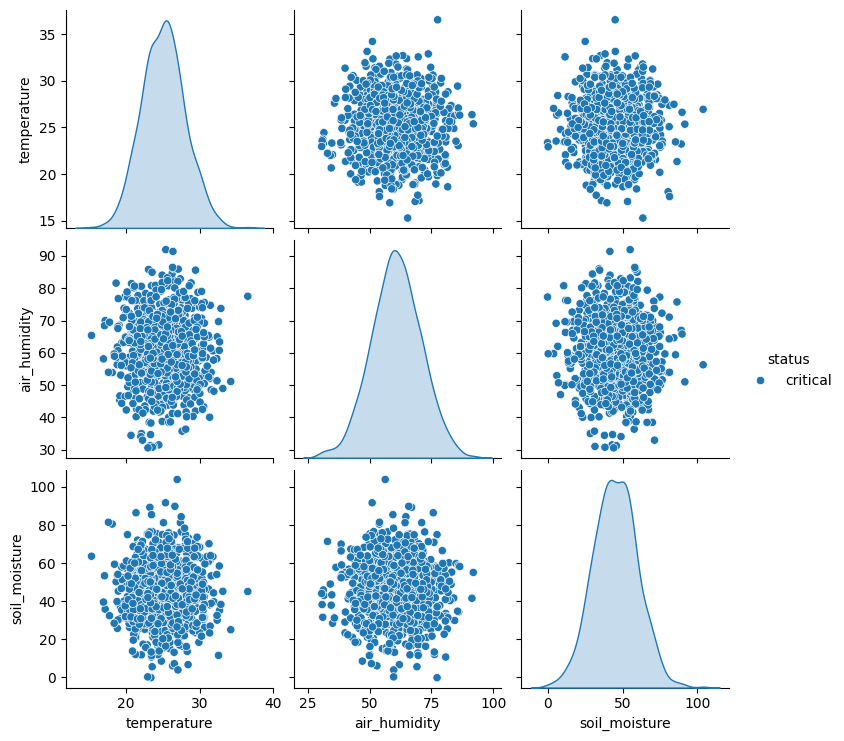

In [37]:
plot_df = df[FEATURES + ['label']].copy()
plot_df['status'] = plot_df['label'].map(CLASS_NAMES)

sns.pairplot(plot_df, hue='status', vars=FEATURES)
plt.savefig(MODEL_DIR/'pairplot.png')
plt.show()

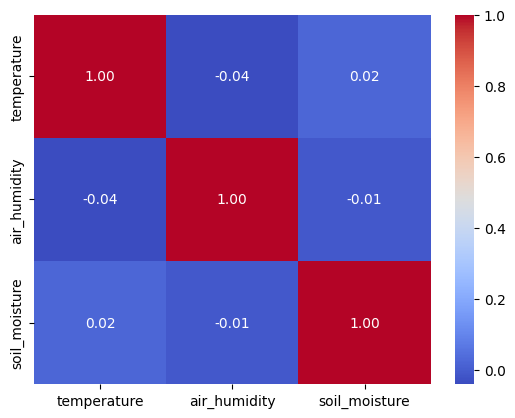

Saved: /Users/duongbinh/Documents/M1/Sensor_to_user/Projects/mushroom-aiot-project/ai_analytics/notebooks/../dataset/raw/plant_health_processed.csv


In [38]:
sns.heatmap(df[FEATURES].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

out = DATA_DIR / 'plant_health_processed.csv'
df[FEATURES + ['label']].to_csv(out, index=False)

print('Saved:', out)